In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from paths import AUDIO_DIR

from dataset import load_metadata, make_dataset

from evaluation import make_sample_weights, majority_vote_prediction, soft_vote_predictions, train_and_evaluate_neural_network, plot_training_history

## Priprema metapodataka

Pregled izvorne tabele i raspodjele kompozitora nalazi se u [metadata.ipynb](metadata.ipynb).
`load_metadata()` iz `dataset.py` učitava CSV, formira `work_id` kao `composer + " | " + composition`
i zadržava kompozitore sa najmanje `MIN_WORKS_PER_COMPOSER` različitih djela (podrazumijevano 5, iz `config.py`).
Svi stavovi istog djela tako ostaju u istoj grupi tokom evaluacije.

Ova sveska se izvršava samostalno; nije potrebno prethodno pokretati `metadata.ipynb`.

In [2]:
metadata_filtered = load_metadata()

print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

NameError: name 'load_metadata' is not defined

# Formiranje X, y, groups

In [10]:
X, y, groups = make_dataset(
    metadata_filtered,
    AUDIO_DIR,
    use_cache=True
)

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

Processing compositions: 100%|█████████████| 302/302 [3:10:22<00:00, 37.82s/it]

X: (4533, 147)
y: (4533,)
groups: (4533,)


In [227]:
Task was destroyed but it is pending!
task: <Task pending name='Task-1222' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1223' coro=<Kernel.shell_main() running at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.12/ast.py:52: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return compile(source, filename, mode, flags,
RuntimeWarning: Enable tracemalloc to get the object allocation traceback
Task was destroyed but it is pending!
task: <Task pending name='Task-1223' coro=<Kernel.shell_main() running at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Task was destroyed but it is pending!
task: <Task pending name='Task-1222' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-1223' coro=<Kernel.shell_main() running at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.12/ast.py:52: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return compile(source, filename, mode, flags,
Task was destroyed but it is pending!
task: <Task pending name='Task-1223' coro=<Kernel.shell_main() running at /home/david/jupyter-test/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


# Isprobavanje potpuno povezanih mreza

<span style="font-size:20px">
Naime, sada cemo isprobati neke potpuno povezane mreze, zbog malog skupa podataka ne ocekujemo previse od njih, ali cemo ih svakako probati. Uglavnom cemo koristiti manje mreze jer bi se vece overfitovale na ovako malom skupu podataka, a svakako nije iskljuceno da ce se to desiti ni sa manjim arhitekturama. 

Mozemo problem posmatrati kao do sada sa podjelom kompozicija na audio segmente, i predvidjanje autora kompozicije na osnovu majority voting-a odradjenog na svim audio segmentima jedne kompozicije. Dakle, princip ostaje isti kao i kod klasicnih modela masinskog ucenja. Takodje cemo isprobati i akumuliranje feature vektora svih segmenata jedne kompozicije u jedan feature vektor za cijelu kompoziciju, sto moze potencijalno biti povoljno za neuronsku mrezu jer nece puno vidjeti isti segment iste kompozicije (sjetimo se da imamo u nasem skupu podataka vise puta istu kompoziciju samo sa razlicitim stavom). 
</span>

In [191]:
class SegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [194]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

label_encoder = LabelEncoder()

#enkodiranje klasa
y_encoded = label_encoder.fit_transform(y)

Device: cpu


In [195]:
#Pravljenje stratified group k foldova

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    sgkf.split(
        X,
        y_encoded,
        groups
    )
)


========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.8354 | val_loss=1.0800 | train_acc=0.6435 | val_acc=0.5713
Epoch 10/20 | train_loss=0.6275 | val_loss=1.1521 | train_acc=0.7377 | val_acc=0.6312
Epoch 15/20 | train_loss=0.5153 | val_loss=1.3292 | train_acc=0.7967 | val_acc=0.6086
Epoch 20/20 | train_loss=0.4491 | val_loss=1.4794 | train_acc=0.8213 | val_acc=0.5950


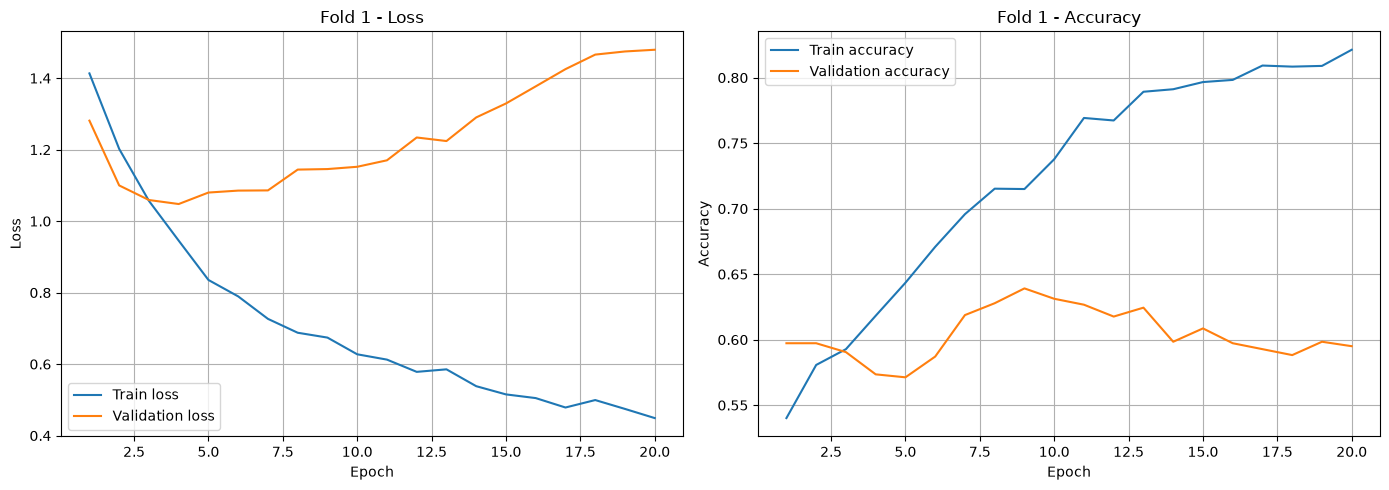

Fold 1: accuracy=0.6364, macro F1=0.3267

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.9218 | val_loss=1.1124 | train_acc=0.6351 | val_acc=0.6059
Epoch 10/20 | train_loss=0.6921 | val_loss=1.0382 | train_acc=0.7164 | val_acc=0.6444
Epoch 15/20 | train_loss=0.5818 | val_loss=1.0978 | train_acc=0.7666 | val_acc=0.6636
Epoch 20/20 | train_loss=0.5091 | val_loss=1.0874 | train_acc=0.7890 | val_acc=0.6920


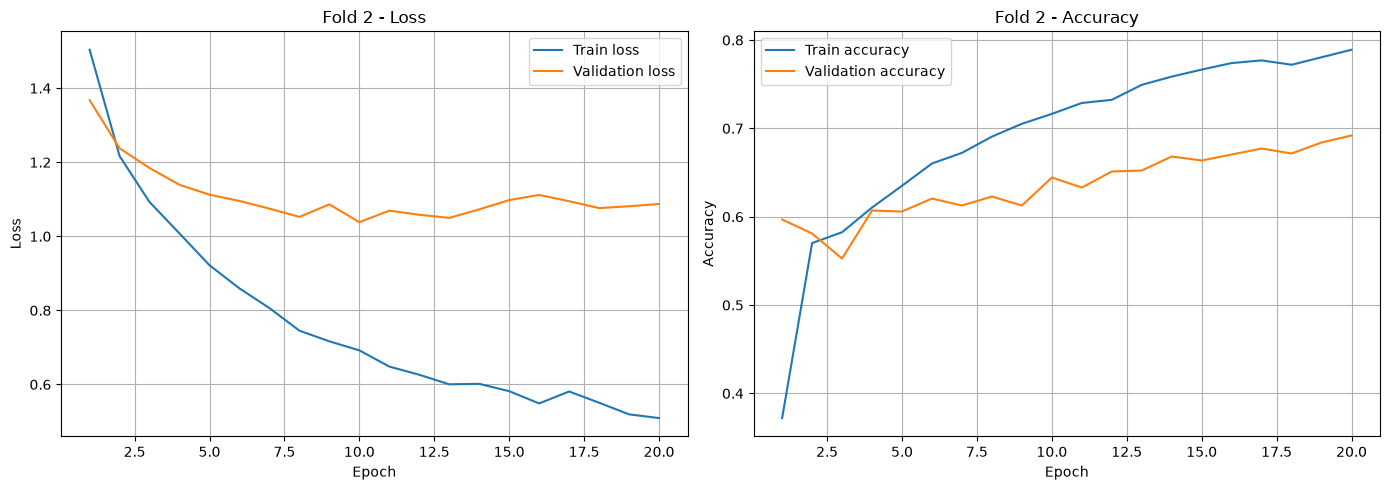

Fold 2: accuracy=0.7273, macro F1=0.4407

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.8760 | val_loss=1.2317 | train_acc=0.6601 | val_acc=0.6411
Epoch 10/20 | train_loss=0.6737 | val_loss=1.5534 | train_acc=0.7220 | val_acc=0.6061
Epoch 15/20 | train_loss=0.5719 | val_loss=1.8302 | train_acc=0.7770 | val_acc=0.6466
Epoch 20/20 | train_loss=0.4955 | val_loss=2.2265 | train_acc=0.8074 | val_acc=0.6772


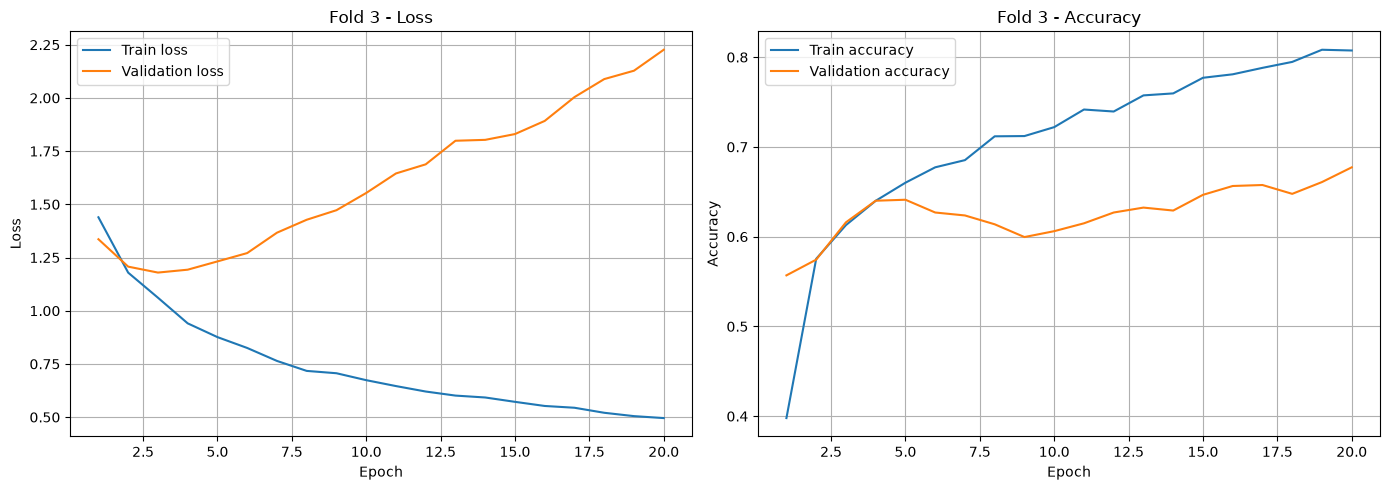

Fold 3: accuracy=0.8636, macro F1=0.6760

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.9097 | val_loss=1.1215 | train_acc=0.6284 | val_acc=0.5518
Epoch 10/20 | train_loss=0.6362 | val_loss=1.1708 | train_acc=0.7418 | val_acc=0.6089
Epoch 15/20 | train_loss=0.5417 | val_loss=1.1777 | train_acc=0.7747 | val_acc=0.6364
Epoch 20/20 | train_loss=0.4878 | val_loss=1.2539 | train_acc=0.7948 | val_acc=0.6374


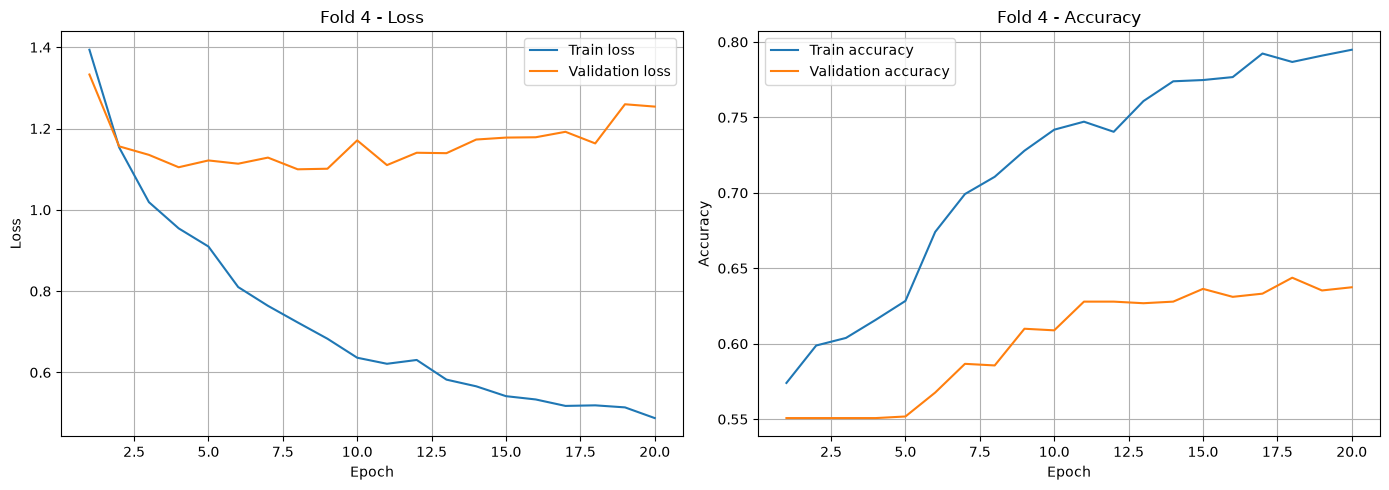

Fold 4: accuracy=0.7826, macro F1=0.4809

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.7668 | val_loss=1.0884 | train_acc=0.7064 | val_acc=0.6015
Epoch 10/20 | train_loss=0.5881 | val_loss=1.1894 | train_acc=0.7604 | val_acc=0.6490
Epoch 15/20 | train_loss=0.4823 | val_loss=1.3303 | train_acc=0.8012 | val_acc=0.6391
Epoch 20/20 | train_loss=0.4216 | val_loss=1.5226 | train_acc=0.8357 | val_acc=0.6302


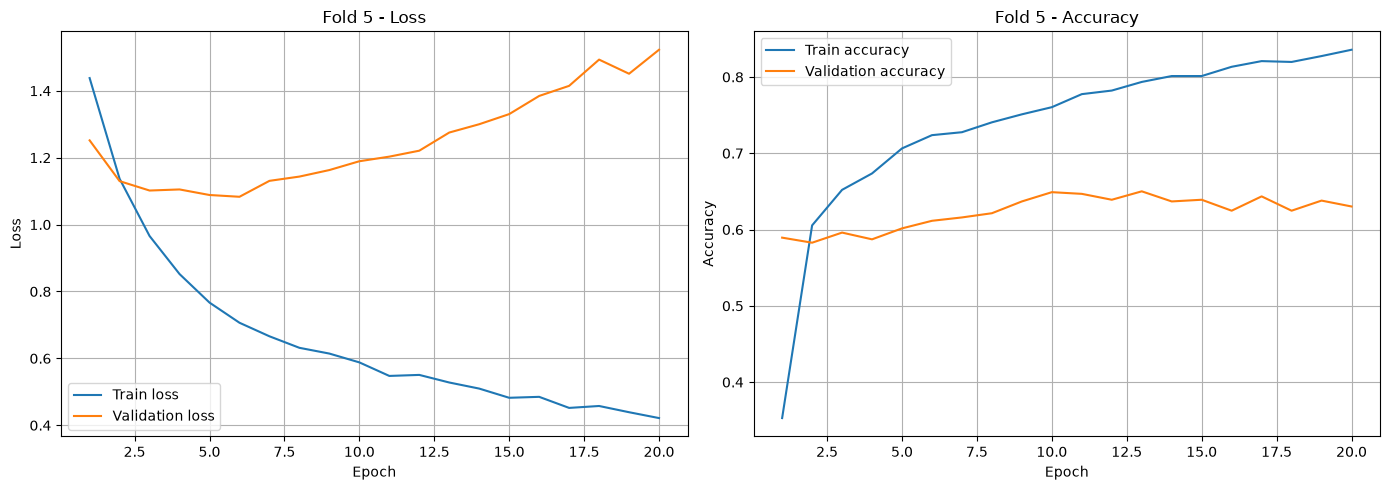

Fold 5: accuracy=0.7500, macro F1=0.5646

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7520
Mean macro F1: 0.4978


In [209]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SegmentNeuralNetwork(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

<span style="font-size:20px">
Mozemo primijetiti znacajno preprilagodjavanje modela neuronske mreze cak i sa ovako malim brojem parametrima, mozemo probati pristup sa dodatnim smanjenjem mreze ili da uvedemo vecu regularizaciju, ili oboje. 
</span>

In [212]:
class SegmentNeuralNetworkRegularized(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


========== FOLD 1 ==========
Epoch 5/20 | train_loss=1.1551 | val_loss=1.0688 | train_acc=0.6081 | val_acc=0.5962
Epoch 10/20 | train_loss=0.9217 | val_loss=1.0505 | train_acc=0.6372 | val_acc=0.6301
Epoch 15/20 | train_loss=0.8463 | val_loss=1.1347 | train_acc=0.6583 | val_acc=0.6505
Epoch 20/20 | train_loss=0.8084 | val_loss=1.1868 | train_acc=0.6725 | val_acc=0.6448


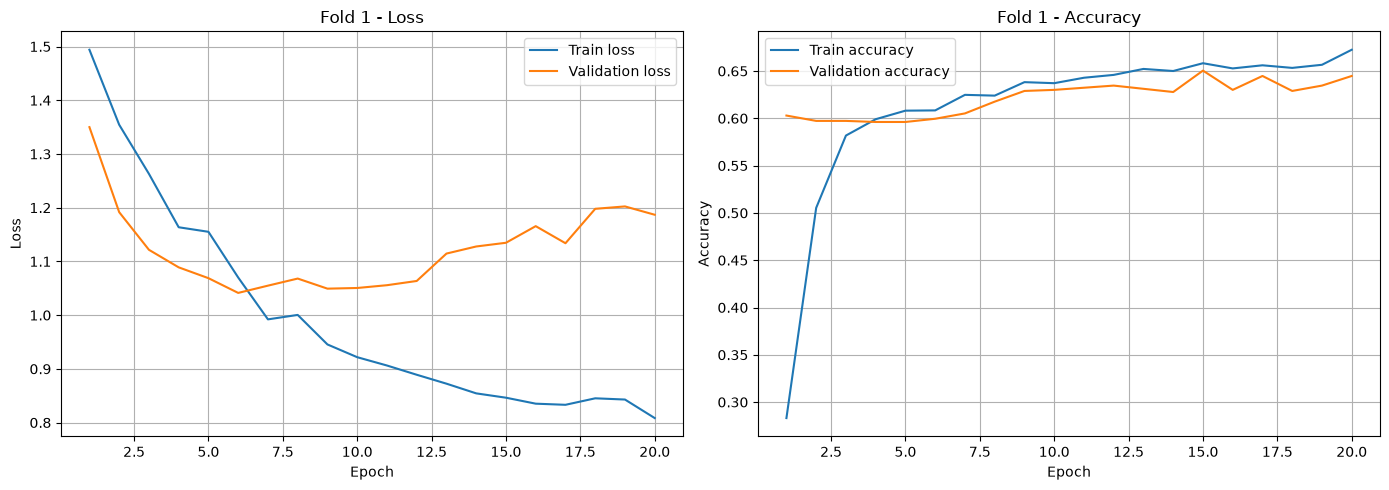

Fold 1: accuracy=0.6818, macro F1=0.3171

========== FOLD 2 ==========
Epoch 5/20 | train_loss=1.0970 | val_loss=1.1743 | train_acc=0.5970 | val_acc=0.6059
Epoch 10/20 | train_loss=0.9517 | val_loss=1.0992 | train_acc=0.6159 | val_acc=0.6693
Epoch 15/20 | train_loss=0.8845 | val_loss=1.0681 | train_acc=0.6323 | val_acc=0.6659
Epoch 20/20 | train_loss=0.8410 | val_loss=1.0589 | train_acc=0.6373 | val_acc=0.6682


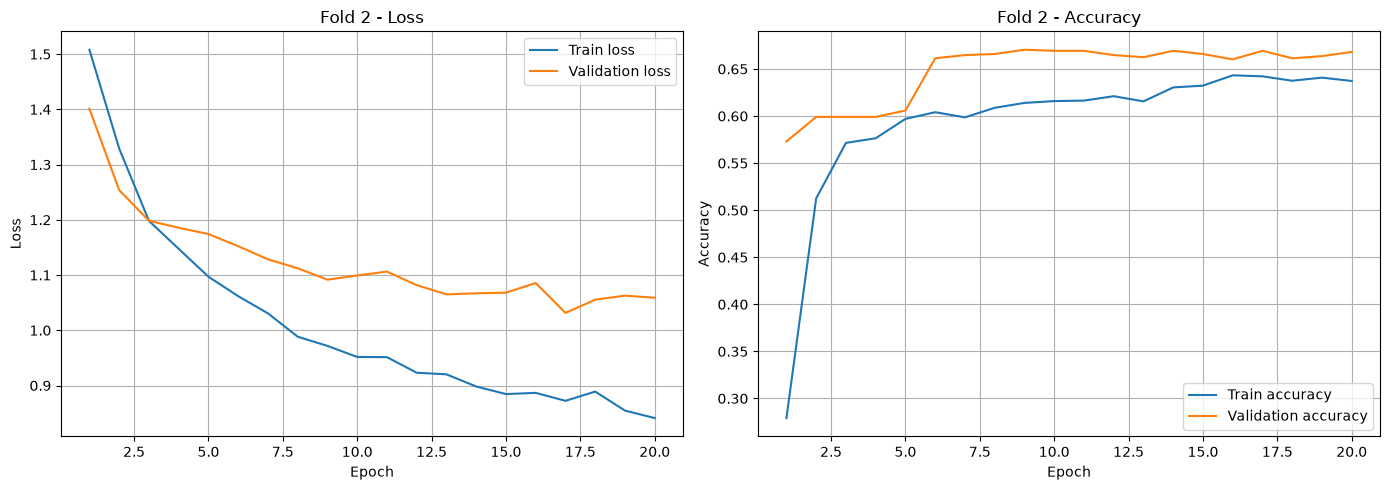

Fold 2: accuracy=0.6818, macro F1=0.3295

========== FOLD 3 ==========
Epoch 5/20 | train_loss=1.0673 | val_loss=1.1726 | train_acc=0.6132 | val_acc=0.5777
Epoch 10/20 | train_loss=0.9279 | val_loss=1.3208 | train_acc=0.6242 | val_acc=0.6532
Epoch 15/20 | train_loss=0.8489 | val_loss=1.4752 | train_acc=0.6364 | val_acc=0.6280
Epoch 20/20 | train_loss=0.7995 | val_loss=1.6318 | train_acc=0.6659 | val_acc=0.6204


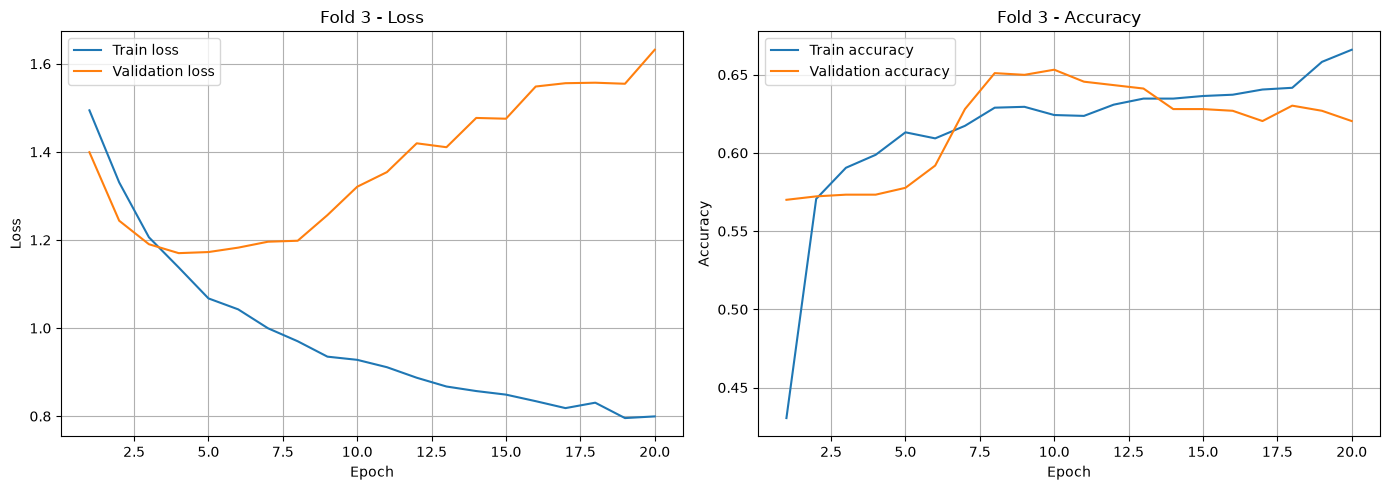

Fold 3: accuracy=0.7273, macro F1=0.3571

========== FOLD 4 ==========
Epoch 5/20 | train_loss=1.0762 | val_loss=1.1501 | train_acc=0.5946 | val_acc=0.5507
Epoch 10/20 | train_loss=0.9287 | val_loss=1.1561 | train_acc=0.5999 | val_acc=0.5518
Epoch 15/20 | train_loss=0.8467 | val_loss=1.1925 | train_acc=0.6156 | val_acc=0.5497
Epoch 20/20 | train_loss=0.7819 | val_loss=1.2986 | train_acc=0.6627 | val_acc=0.5592


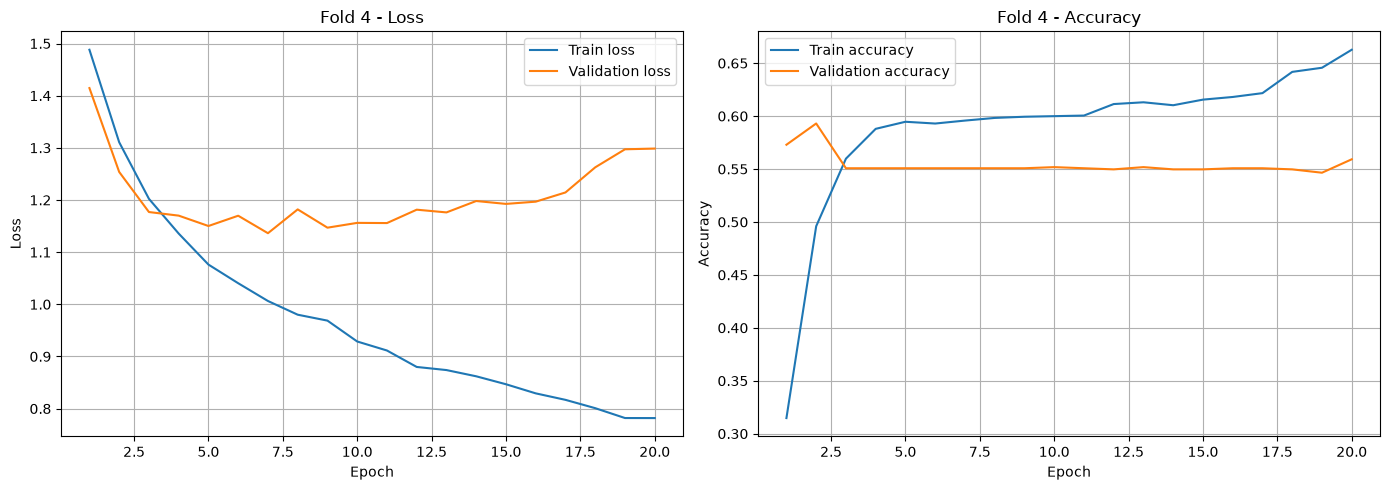

Fold 4: accuracy=0.5217, macro F1=0.1833

========== FOLD 5 ==========
Epoch 5/20 | train_loss=1.1149 | val_loss=1.1291 | train_acc=0.5773 | val_acc=0.5784
Epoch 10/20 | train_loss=0.9152 | val_loss=1.1686 | train_acc=0.6438 | val_acc=0.6071
Epoch 15/20 | train_loss=0.8512 | val_loss=1.2437 | train_acc=0.6465 | val_acc=0.6170
Epoch 20/20 | train_loss=0.7826 | val_loss=1.3349 | train_acc=0.6617 | val_acc=0.6225


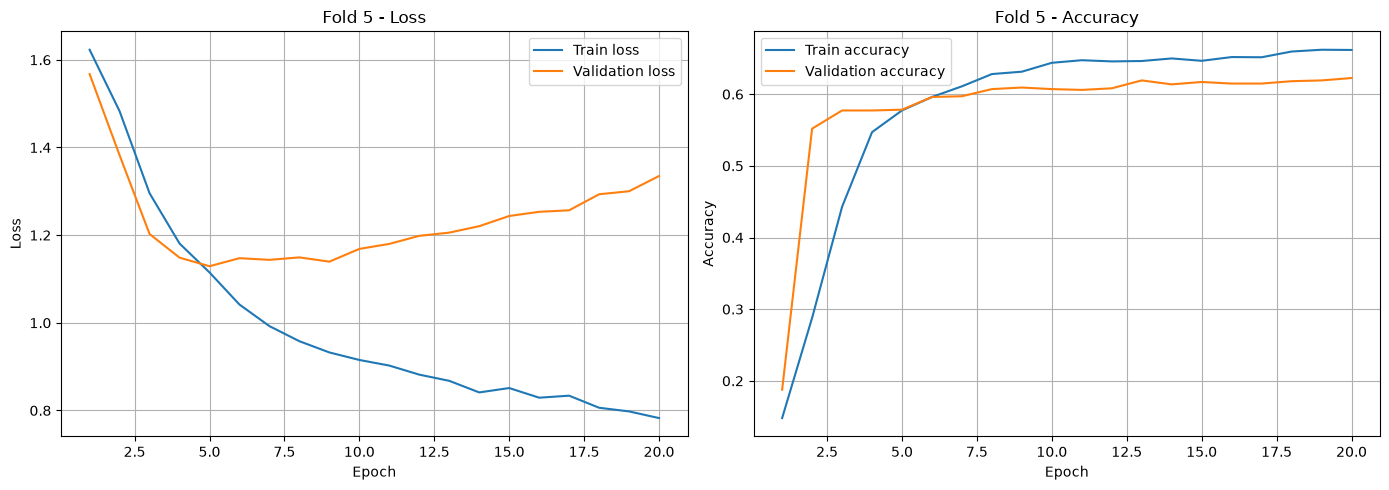

Fold 5: accuracy=0.7083, macro F1=0.3363

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6642
Mean macro F1: 0.3047


In [215]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SegmentNeuralNetworkRegularized(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

In [216]:
class SmallSegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


========== FOLD 1 ==========
Epoch 5/20 | train_loss=1.0195 | val_loss=1.0589 | train_acc=0.5821 | val_acc=0.5916
Epoch 10/20 | train_loss=0.8052 | val_loss=1.2357 | train_acc=0.6506 | val_acc=0.5464
Epoch 15/20 | train_loss=0.6535 | val_loss=1.3559 | train_acc=0.7284 | val_acc=0.5215
Epoch 20/20 | train_loss=0.5938 | val_loss=1.4300 | train_acc=0.7577 | val_acc=0.5452


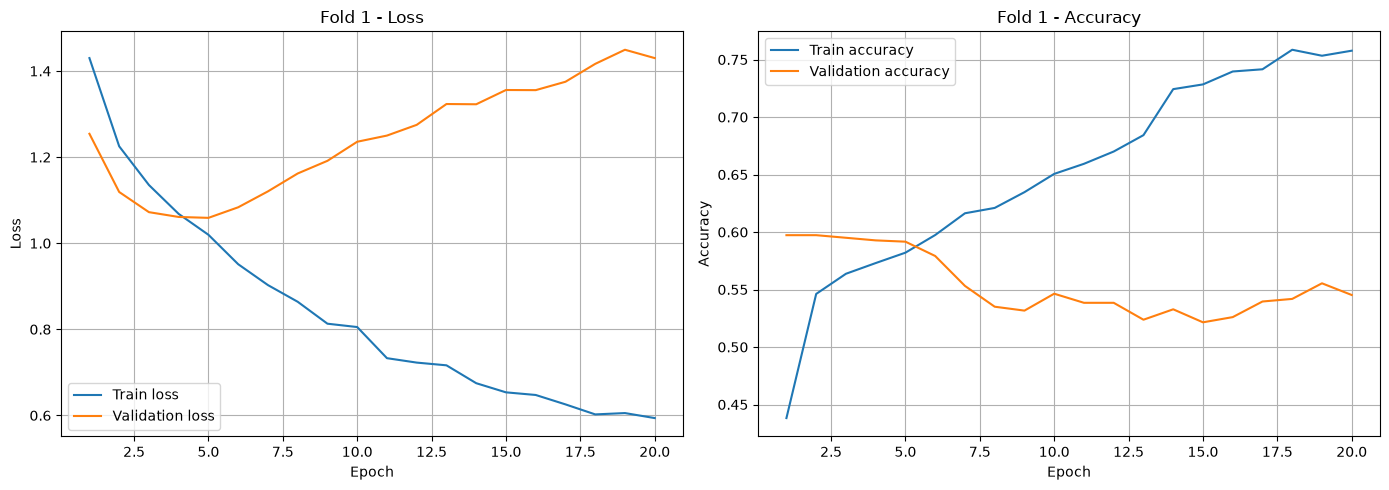

Fold 1: accuracy=0.4545, macro F1=0.1379

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.9597 | val_loss=1.1061 | train_acc=0.6471 | val_acc=0.5561
Epoch 10/20 | train_loss=0.7720 | val_loss=1.0657 | train_acc=0.6926 | val_acc=0.6263
Epoch 15/20 | train_loss=0.6992 | val_loss=1.0232 | train_acc=0.7101 | val_acc=0.6670
Epoch 20/20 | train_loss=0.6200 | val_loss=1.0384 | train_acc=0.7367 | val_acc=0.6772


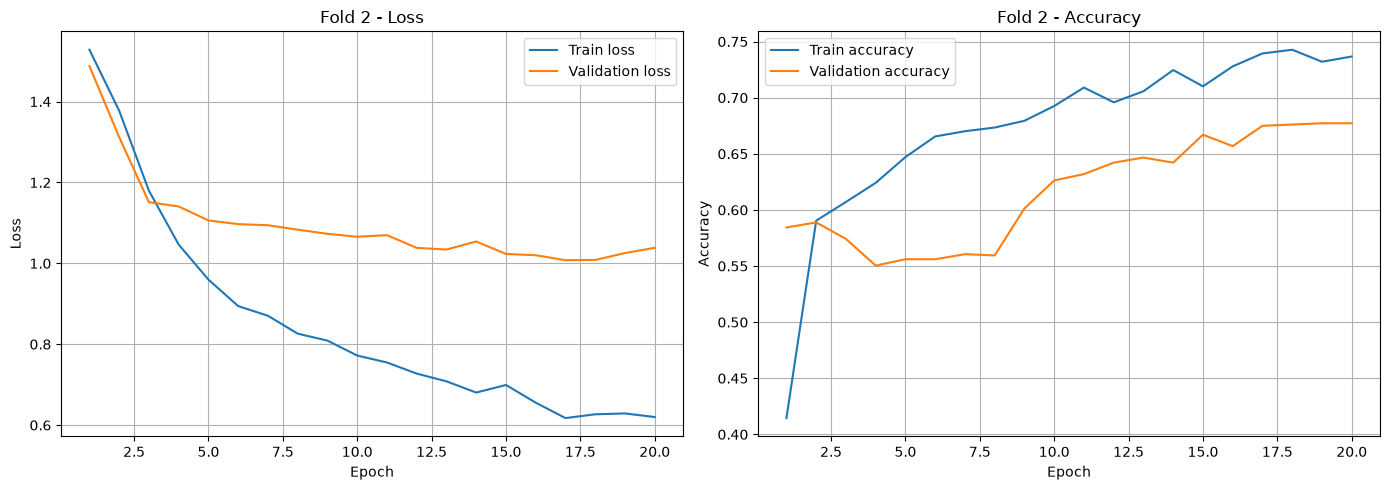

Fold 2: accuracy=0.7273, macro F1=0.4349

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.9813 | val_loss=1.1944 | train_acc=0.6690 | val_acc=0.5733
Epoch 10/20 | train_loss=0.7316 | val_loss=1.4131 | train_acc=0.7339 | val_acc=0.6204
Epoch 15/20 | train_loss=0.6126 | val_loss=1.6495 | train_acc=0.7787 | val_acc=0.6652
Epoch 20/20 | train_loss=0.5485 | val_loss=1.8586 | train_acc=0.7988 | val_acc=0.6849


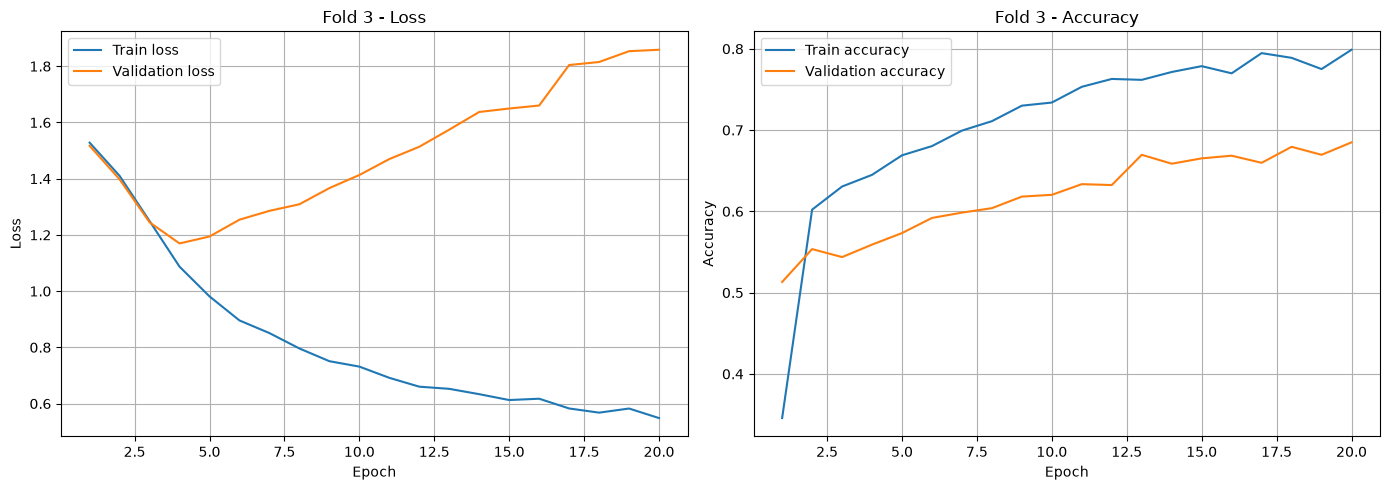

Fold 3: accuracy=0.8182, macro F1=0.6026

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.9894 | val_loss=1.1310 | train_acc=0.5969 | val_acc=0.5486
Epoch 10/20 | train_loss=0.7655 | val_loss=1.1040 | train_acc=0.6666 | val_acc=0.6152
Epoch 15/20 | train_loss=0.6229 | val_loss=1.1702 | train_acc=0.7435 | val_acc=0.6353
Epoch 20/20 | train_loss=0.5786 | val_loss=1.2836 | train_acc=0.7510 | val_acc=0.6216


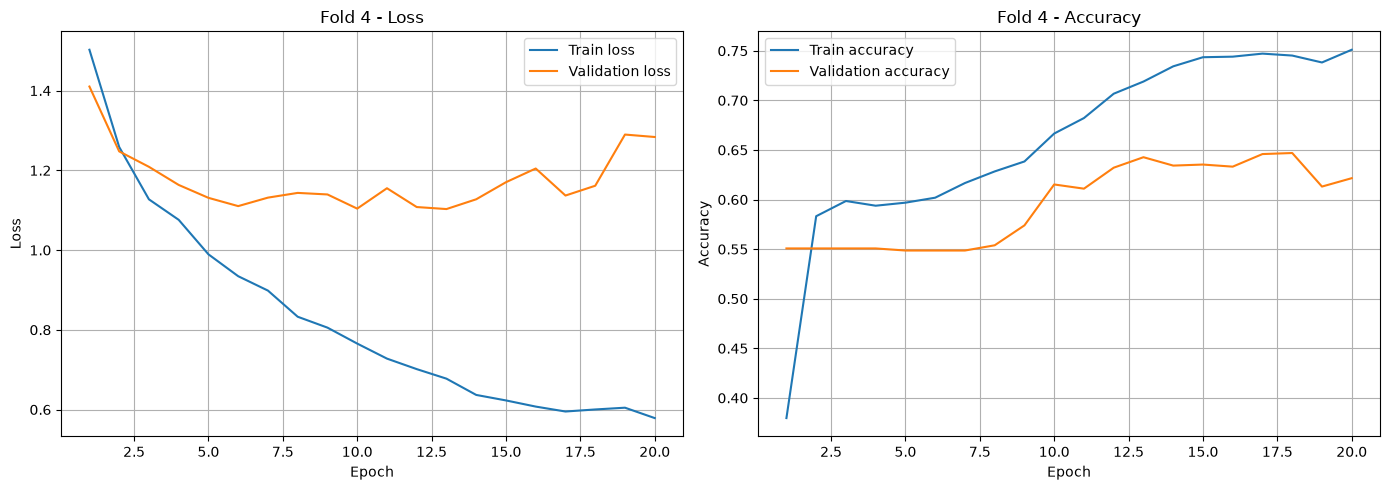

Fold 4: accuracy=0.7391, macro F1=0.3418

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.8898 | val_loss=1.0005 | train_acc=0.6435 | val_acc=0.6269
Epoch 10/20 | train_loss=0.6686 | val_loss=0.9861 | train_acc=0.7276 | val_acc=0.6578
Epoch 15/20 | train_loss=0.5630 | val_loss=1.0990 | train_acc=0.7648 | val_acc=0.6556
Epoch 20/20 | train_loss=0.4977 | val_loss=1.2453 | train_acc=0.7775 | val_acc=0.6369


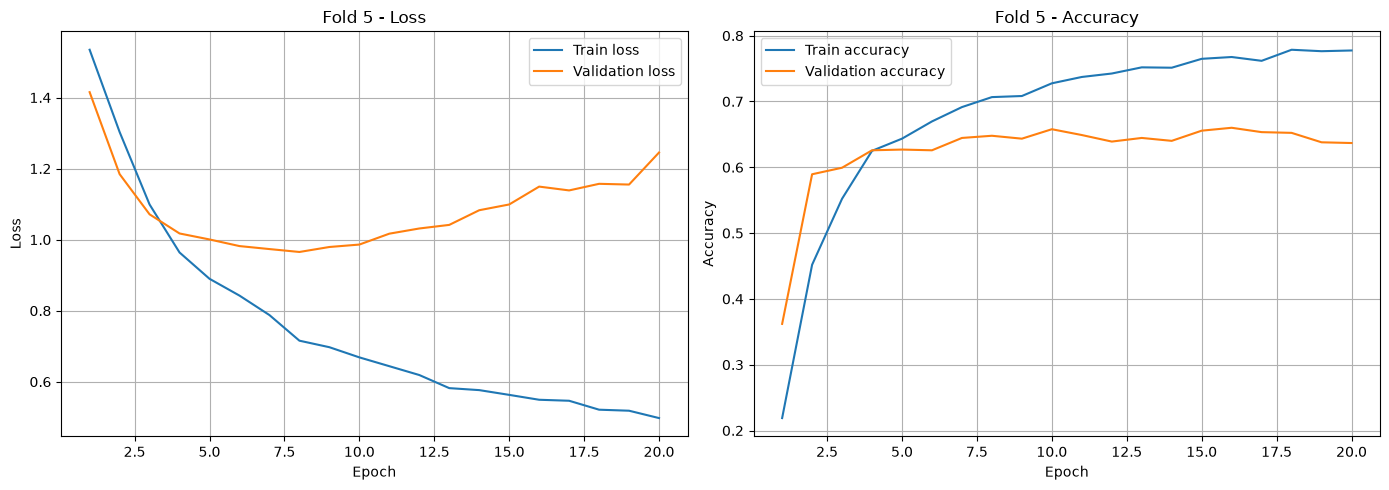

Fold 5: accuracy=0.7083, macro F1=0.4718

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6895
Mean macro F1: 0.3978


In [217]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

fold_accuracies = []
fold_f1_scores = []

all_work_true = []
all_work_pred = []


for fold, (train_idx, test_idx) in enumerate(folds, start=1):

    print(f"\n========== FOLD {fold} ==========")

    # PODACI
    X_train = X[train_idx]
    y_train = y_encoded[train_idx]

    X_test = X[test_idx]
    y_test = y_encoded[test_idx]

    groups_test = groups[test_idx]


    # STANDARDIZACIJA
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # TRAIN DATASET + LOADER
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # MODEL
    model = SmallSegmentNeuralNetwork(
        input_size=X.shape[1],
        num_classes=len(label_encoder.classes_)
    ).to(device)


    # LOSS
    criterion = nn.CrossEntropyLoss()


    # OPTIMIZER
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =====================================================
    # OVDJE POZIVAMO FUNKCIJU ZA TRENING
    # =====================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # GRAFICI
    plot_training_history(
        history,
        fold=fold
    )


    # TEST PREDIKCIJE
    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        pred = torch.argmax(logits, dim=1).cpu().numpy()


    # MAJORITY VOTE PO DJELU
    work_true, work_pred = majority_vote_prediction(
        y_test,
        pred,
        groups_test
    )


    # METRIKE
    accuracy = metrics.accuracy_score(
        work_true,
        work_pred
    )

    f1 = metrics.f1_score(
        work_true,
        work_pred,
        average="macro"
    )

    fold_accuracies.append(accuracy)
    fold_f1_scores.append(f1)

    all_work_true.extend(work_true)
    all_work_pred.extend(work_pred)

    print(
        f"Fold {fold}: "
        f"accuracy={accuracy:.4f}, "
        f"macro F1={f1:.4f}"
    )


print("\n========== UKUPNI REZULTATI ==========")

print(
    f"Mean accuracy: {np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean macro F1: {np.mean(fold_f1_scores):.4f}"
)

<span style="font-size:20px">
Naime, nijedan od navedenih pristupa nije urodio plodom, u svakom slucaju se neuronska mreza preprilagodjavala. Mozemo pokusati sada klasifikaciju gdje akumuliramo feature vektore svih segmenata u jedan feature vektor koji ce da koristi cijela kompozicija
</span>

In [218]:
import numpy as np

def make_work_level_dataset(X, y, groups):

    X_work = []
    y_work = []
    work_ids = []

    for work_id in np.unique(groups):

        mask = groups == work_id

        X_segments = X[mask]
        y_segments = y[mask]

        mean_features = X_segments.mean(axis=0)
        std_features = X_segments.std(axis=0)

        work_features = np.concatenate([
            mean_features,
            std_features
        ])

        X_work.append(work_features)
        y_work.append(y_segments[0])
        work_ids.append(work_id)

    X_work = np.array(X_work)
    y_work = np.array(y_work)
    work_ids = np.array(work_ids)

    return X_work, y_work, work_ids

In [219]:
X_work, y_work, work_ids = make_work_level_dataset(X,y,groups)

In [220]:
class WorkNN_Small(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']
Class counts: (array([0, 1, 2, 3, 4]), array([30, 55,  8, 11,  9]))

========== FOLD 1 ==========
Epoch 5/30 | train_loss=1.1605 | val_loss=1.1660 | train_acc=0.5556 | val_acc=0.6087
Epoch 10/30 | train_loss=0.8335 | val_loss=0.9369 | train_acc=0.7000 | val_acc=0.6087
Epoch 15/30 | train_loss=0.6810 | val_loss=0.8421 | train_acc=0.7444 | val_acc=0.6522
Epoch 20/30 | train_loss=0.5669 | val_loss=0.7939 | train_acc=0.8444 | val_acc=0.6522
Epoch 25/30 | train_loss=0.5183 | val_loss=0.7635 | train_acc=0.8444 | val_acc=0.6522
Epoch 30/30 | train_loss=0.4977 | val_loss=0.7539 | train_acc=0.8333 | val_acc=0.6522


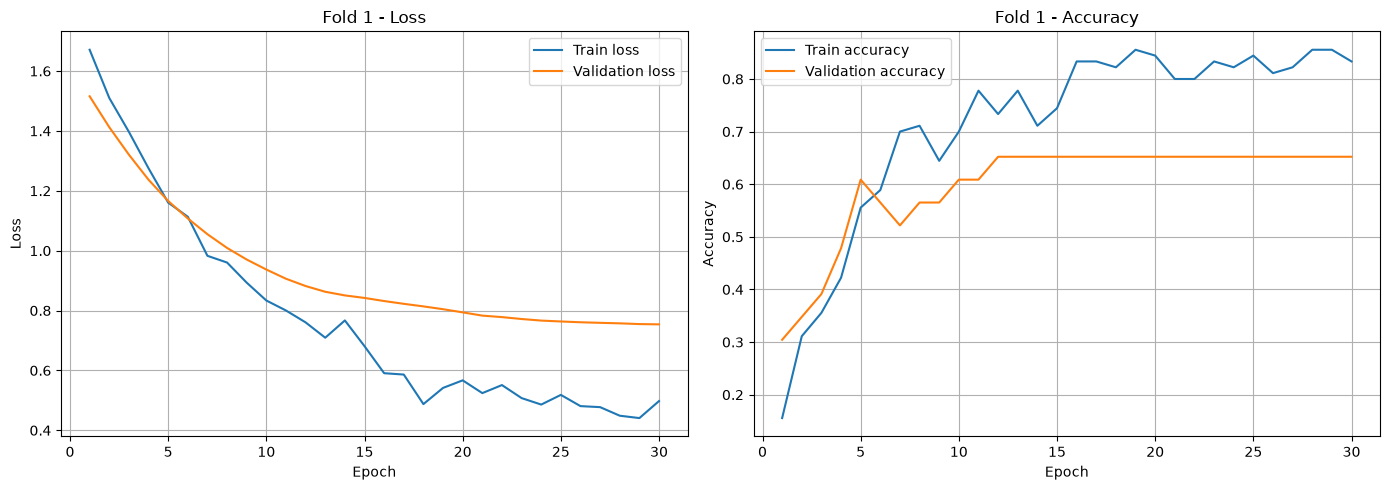


Fold 1 results:
Accuracy: 0.6522
Macro F1: 0.3040
Final train loss: 0.4977
Final validation loss: 0.7539

========== FOLD 2 ==========
Epoch 5/30 | train_loss=1.1019 | val_loss=1.2884 | train_acc=0.6889 | val_acc=0.4783
Epoch 10/30 | train_loss=0.7641 | val_loss=1.1616 | train_acc=0.7667 | val_acc=0.6087
Epoch 15/30 | train_loss=0.6313 | val_loss=1.1224 | train_acc=0.8444 | val_acc=0.6522
Epoch 20/30 | train_loss=0.5010 | val_loss=1.1278 | train_acc=0.8889 | val_acc=0.6522
Epoch 25/30 | train_loss=0.4265 | val_loss=1.1396 | train_acc=0.8667 | val_acc=0.6522
Epoch 30/30 | train_loss=0.2852 | val_loss=1.1480 | train_acc=0.9222 | val_acc=0.6957


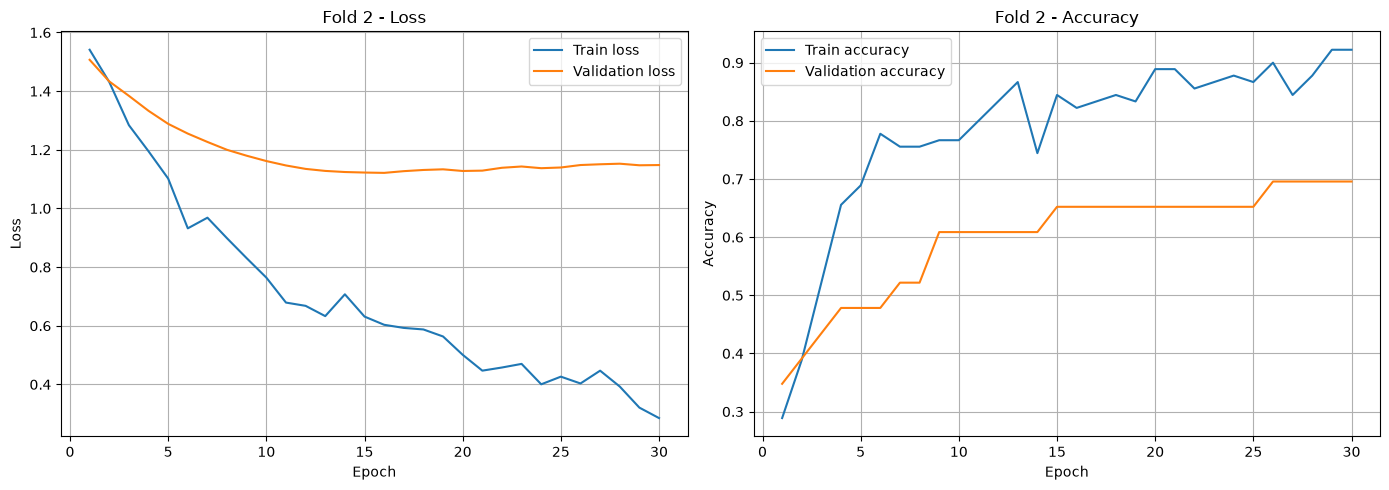


Fold 2 results:
Accuracy: 0.6957
Macro F1: 0.4078
Final train loss: 0.2852
Final validation loss: 1.1480

========== FOLD 3 ==========
Epoch 5/30 | train_loss=1.3535 | val_loss=1.2759 | train_acc=0.4444 | val_acc=0.5652
Epoch 10/30 | train_loss=1.0102 | val_loss=0.8740 | train_acc=0.7667 | val_acc=0.7826
Epoch 15/30 | train_loss=0.7483 | val_loss=0.6564 | train_acc=0.7889 | val_acc=0.7826
Epoch 20/30 | train_loss=0.5284 | val_loss=0.5660 | train_acc=0.8556 | val_acc=0.7826
Epoch 25/30 | train_loss=0.4388 | val_loss=0.5103 | train_acc=0.8556 | val_acc=0.7826
Epoch 30/30 | train_loss=0.3402 | val_loss=0.4769 | train_acc=0.9111 | val_acc=0.7826


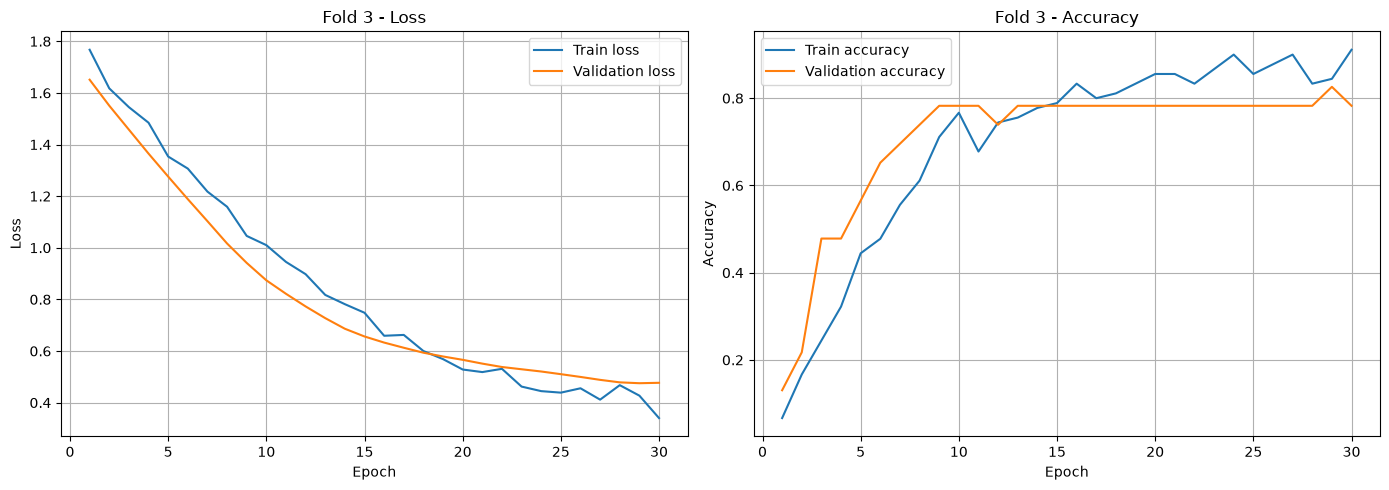


Fold 3 results:
Accuracy: 0.7826
Macro F1: 0.5919
Final train loss: 0.3402
Final validation loss: 0.4769

========== FOLD 4 ==========
Epoch 5/30 | train_loss=1.1205 | val_loss=1.1750 | train_acc=0.6703 | val_acc=0.6818
Epoch 10/30 | train_loss=0.8303 | val_loss=0.9184 | train_acc=0.7033 | val_acc=0.6818
Epoch 15/30 | train_loss=0.6565 | val_loss=0.8169 | train_acc=0.8681 | val_acc=0.6818
Epoch 20/30 | train_loss=0.4919 | val_loss=0.7839 | train_acc=0.8462 | val_acc=0.6818
Epoch 25/30 | train_loss=0.3997 | val_loss=0.7728 | train_acc=0.9011 | val_acc=0.6818
Epoch 30/30 | train_loss=0.3649 | val_loss=0.7582 | train_acc=0.8791 | val_acc=0.6818


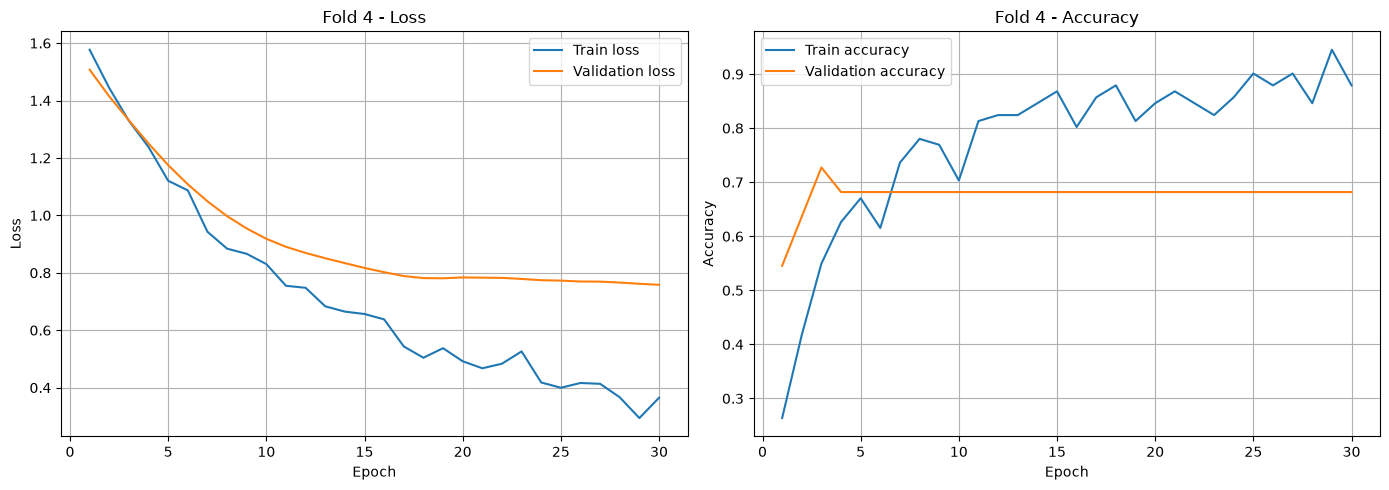


Fold 4 results:
Accuracy: 0.6818
Macro F1: 0.3267
Final train loss: 0.3649
Final validation loss: 0.7582

========== FOLD 5 ==========
Epoch 5/30 | train_loss=1.1634 | val_loss=1.2475 | train_acc=0.6264 | val_acc=0.5000
Epoch 10/30 | train_loss=0.8791 | val_loss=0.9792 | train_acc=0.7143 | val_acc=0.6818
Epoch 15/30 | train_loss=0.6597 | val_loss=0.8633 | train_acc=0.7912 | val_acc=0.7727
Epoch 20/30 | train_loss=0.5055 | val_loss=0.7909 | train_acc=0.8462 | val_acc=0.7273
Epoch 25/30 | train_loss=0.4434 | val_loss=0.7529 | train_acc=0.8571 | val_acc=0.6818
Epoch 30/30 | train_loss=0.3510 | val_loss=0.7505 | train_acc=0.9011 | val_acc=0.7273


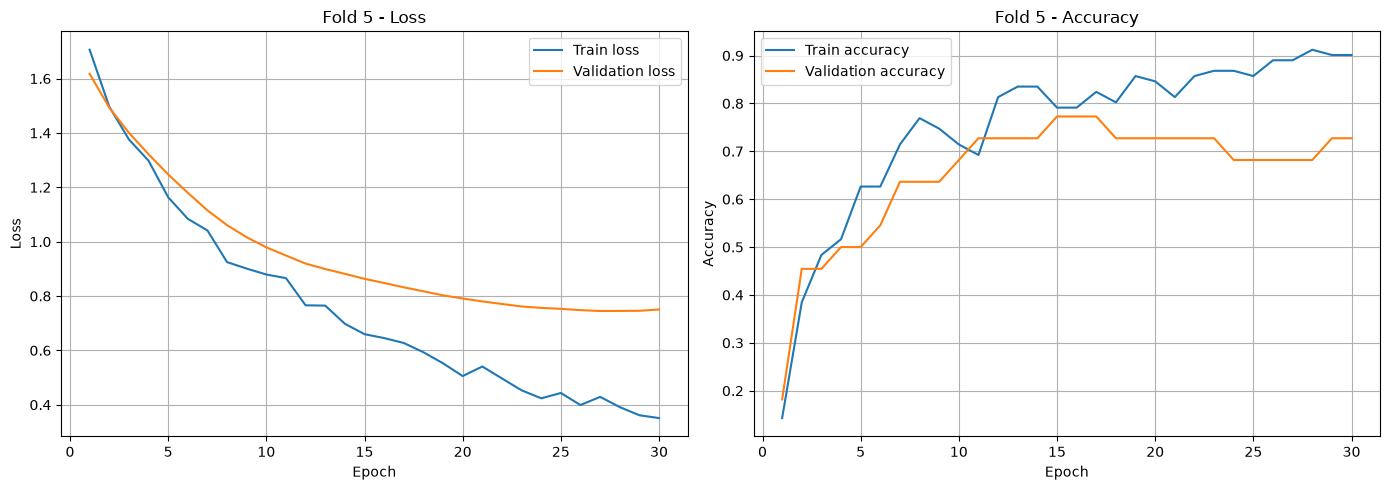


Fold 5 results:
Accuracy: 0.7273
Macro F1: 0.5103
Final train loss: 0.3510
Final validation loss: 0.7505

========== GENERAL RESULTS ==========
Mean Accuracy: 0.7079
Mean Macro F1: 0.4281

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        Bach       0.77      0.90      0.83        30
   Beethoven       0.76      0.87      0.81        55
      Brahms       0.25      0.12      0.17         8
      Mozart       0.38      0.27      0.32        11
    Schubert       0.33      0.11      0.17         9

    accuracy                           0.71       113
   macro avg       0.50      0.46      0.46       113
weighted avg       0.66      0.71      0.67       113



In [222]:
import numpy as np
import torch
import torch.nn as nn

from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import TensorDataset, DataLoader

from evaluation import (
    train_and_evaluate_neural_network,
    plot_training_history
)


# ============================================================
# CUDA
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder_work = LabelEncoder()

y_work_encoded = label_encoder_work.fit_transform(
    y_work
)

print("Classes:", label_encoder_work.classes_)

print(
    "Class counts:",
    np.unique(
        y_work_encoded,
        return_counts=True
    )
)


# ============================================================
# FOLDOVI
# Jedan red = jedno djelo, tako da nam groups vise ne treba
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

work_folds = list(
    skf.split(
        X_work,
        y_work_encoded
    )
)


# ============================================================
# PARAMETRI
# ============================================================

EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.001


# ============================================================
# IZABERI MREZU
# ============================================================

# Promijeni samo ovu liniju kada hoces drugu arhitekturu:
MODEL_CLASS = WorkNN_Small

# npr:
# MODEL_CLASS = WorkNN_Medium
# MODEL_CLASS = WorkNN_Large


# ============================================================
# REZULTATI
# ============================================================

fold_accuracies = []
fold_f1_scores = []

all_true = []
all_pred = []


# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    work_folds,
    start=1
):

    print(f"\n========== FOLD {fold} ==========")


    # --------------------------------------------------------
    # TRAIN / TEST
    # --------------------------------------------------------

    X_train = X_work[train_idx]
    y_train = y_work_encoded[train_idx]

    X_test = X_work[test_idx]
    y_test = y_work_encoded[test_idx]


    # --------------------------------------------------------
    # STANDARDIZACIJA
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # --------------------------------------------------------
    # TENSORI ZA TRAIN
    # --------------------------------------------------------

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )


    # --------------------------------------------------------
    # DATASET + DATALOADER
    # --------------------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # --------------------------------------------------------
    # NOV MODEL ZA SVAKI FOLD
    # --------------------------------------------------------

    model = MODEL_CLASS(
        input_size=X_work.shape[1],
        num_classes=len(
            label_encoder_work.classes_
        )
    ).to(device)


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # ========================================================
    # TRENING + EVALUACIJA
    # ========================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # ========================================================
    # PLOT ZA OVAJ FOLD
    # ========================================================

    plot_training_history(
        history,
        fold=fold
    )


    # ========================================================
    # FINALNE PREDIKCIJE OVOG FOLDA
    # ========================================================

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor
        )

        predictions = torch.argmax(
            logits,
            dim=1
        ).cpu().numpy()


    # ========================================================
    # METRIKE
    # ========================================================

    accuracy = metrics.accuracy_score(
        y_test,
        predictions
    )

    f1 = metrics.f1_score(
        y_test,
        predictions,
        average="macro"
    )


    fold_accuracies.append(
        accuracy
    )

    fold_f1_scores.append(
        f1
    )

    all_true.extend(
        y_test
    )

    all_pred.extend(
        predictions
    )


    print(
        f"\nFold {fold} results:"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro F1: {f1:.4f}"
    )

    print(
        f"Final train loss: "
        f"{history['train_loss'][-1]:.4f}"
    )

    print(
        f"Final validation loss: "
        f"{history['val_loss'][-1]:.4f}"
    )


# ============================================================
# UKUPNI REZULTATI
# ============================================================

print(
    "\n========== GENERAL RESULTS =========="
)

print(
    f"Mean Accuracy: "
    f"{np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(fold_f1_scores):.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    metrics.classification_report(
        all_true,
        all_pred,
        labels=range(
            len(label_encoder_work.classes_)
        ),
        target_names=
            label_encoder_work.classes_,
        zero_division=0
    )
)

In [223]:
# Vidimo da smo uspjeli da poboljsamo rezultate po pitanju preprilagodjavanja

In [224]:
class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']
Class counts: (array([0, 1, 2, 3, 4]), array([30, 55,  8, 11,  9]))

========== FOLD 1 ==========
Epoch 5/60 | train_loss=1.3521 | val_loss=1.3214 | train_acc=0.4222 | val_acc=0.4348
Epoch 10/60 | train_loss=1.0708 | val_loss=1.2052 | train_acc=0.5556 | val_acc=0.5217
Epoch 15/60 | train_loss=1.0133 | val_loss=1.1686 | train_acc=0.5000 | val_acc=0.5217
Epoch 20/60 | train_loss=0.9574 | val_loss=1.1407 | train_acc=0.7222 | val_acc=0.7391
Epoch 25/60 | train_loss=0.8409 | val_loss=1.1381 | train_acc=0.8000 | val_acc=0.7391
Epoch 30/60 | train_loss=0.8307 | val_loss=1.1639 | train_acc=0.7778 | val_acc=0.7391
Epoch 35/60 | train_loss=0.8761 | val_loss=1.1781 | train_acc=0.7556 | val_acc=0.6957
Epoch 40/60 | train_loss=0.7621 | val_loss=1.1848 | train_acc=0.8000 | val_acc=0.7391
Epoch 45/60 | train_loss=0.7841 | val_loss=1.2019 | train_acc=0.8222 | val_acc=0.6957
Epoch 50/60 | train_loss=0.7494 | val_loss=1.2199 | train_

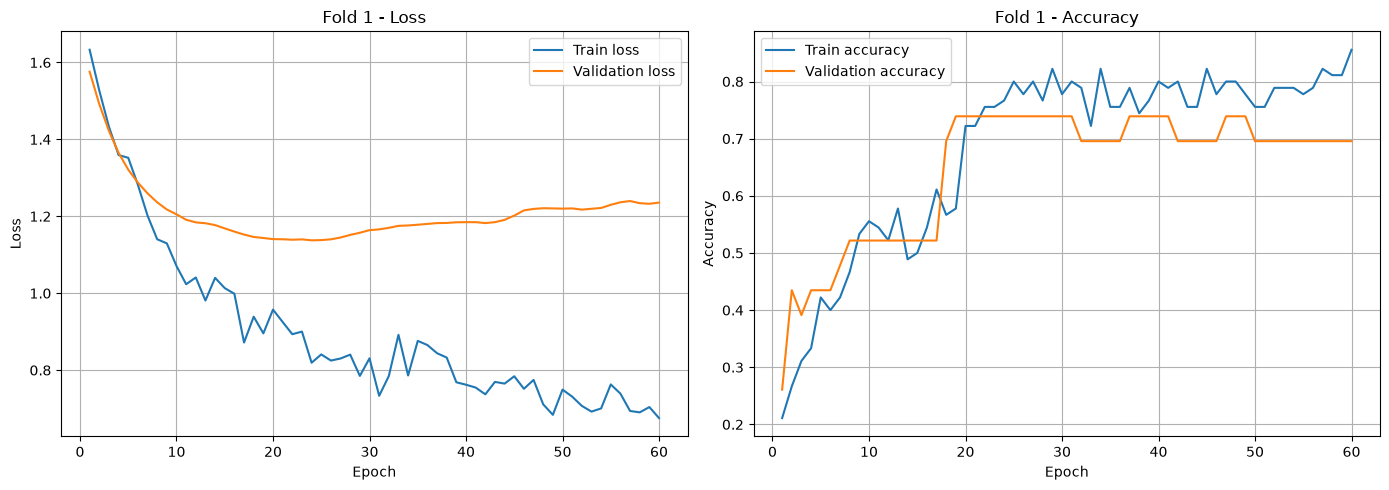


---------- FOLD 1 RESULTS ----------
Accuracy: 0.6957
Macro F1: 0.4030
Final train loss: 0.6754
Final validation loss: 1.2356

========== FOLD 2 ==========
Epoch 5/60 | train_loss=1.3713 | val_loss=1.4027 | train_acc=0.3333 | val_acc=0.2609
Epoch 10/60 | train_loss=1.1708 | val_loss=1.2526 | train_acc=0.5111 | val_acc=0.4783
Epoch 15/60 | train_loss=0.9991 | val_loss=1.1613 | train_acc=0.6000 | val_acc=0.5652
Epoch 20/60 | train_loss=0.8277 | val_loss=1.0638 | train_acc=0.6889 | val_acc=0.6087
Epoch 25/60 | train_loss=0.8667 | val_loss=1.0613 | train_acc=0.6444 | val_acc=0.6522
Epoch 30/60 | train_loss=0.6942 | val_loss=1.0091 | train_acc=0.7222 | val_acc=0.6957
Epoch 35/60 | train_loss=0.7049 | val_loss=1.0081 | train_acc=0.7000 | val_acc=0.6957
Epoch 40/60 | train_loss=0.5966 | val_loss=1.0285 | train_acc=0.7222 | val_acc=0.6957
Epoch 45/60 | train_loss=0.5408 | val_loss=1.0328 | train_acc=0.7889 | val_acc=0.6957
Epoch 50/60 | train_loss=0.6224 | val_loss=1.0555 | train_acc=0.7444 |

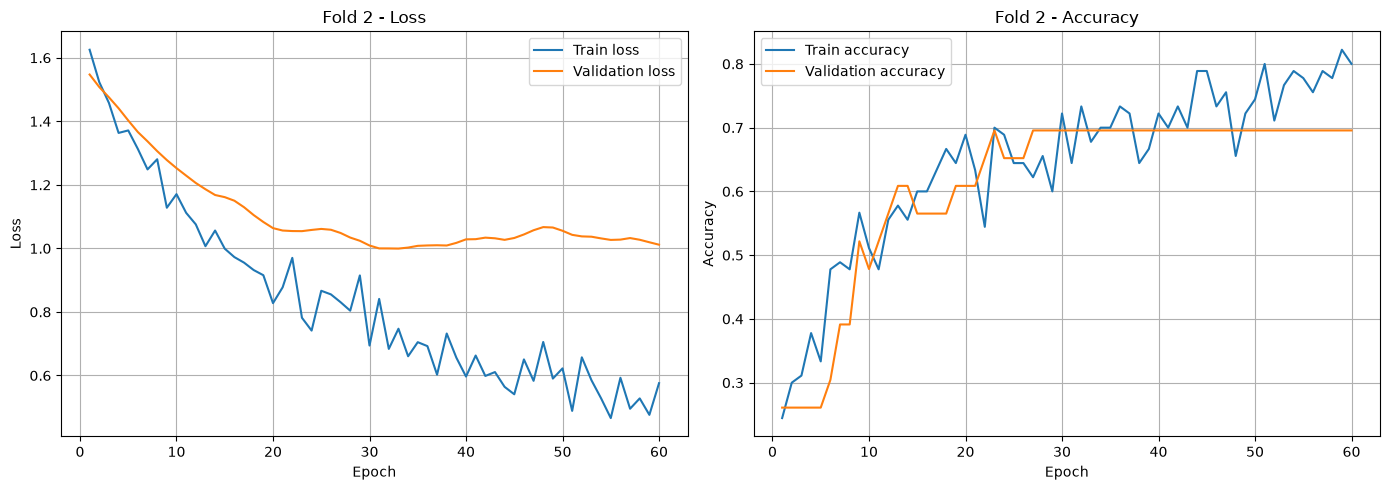


---------- FOLD 2 RESULTS ----------
Accuracy: 0.6957
Macro F1: 0.4205
Final train loss: 0.5758
Final validation loss: 1.0116

========== FOLD 3 ==========
Epoch 5/60 | train_loss=1.4707 | val_loss=1.4052 | train_acc=0.2222 | val_acc=0.3913
Epoch 10/60 | train_loss=1.2481 | val_loss=1.2276 | train_acc=0.6000 | val_acc=0.5217
Epoch 15/60 | train_loss=1.1221 | val_loss=1.0530 | train_acc=0.6667 | val_acc=0.7826
Epoch 20/60 | train_loss=1.0190 | val_loss=0.8916 | train_acc=0.6889 | val_acc=0.6522
Epoch 25/60 | train_loss=0.8658 | val_loss=0.7713 | train_acc=0.7444 | val_acc=0.6522
Epoch 30/60 | train_loss=0.9455 | val_loss=0.7072 | train_acc=0.6889 | val_acc=0.6522
Epoch 35/60 | train_loss=0.7425 | val_loss=0.6622 | train_acc=0.7778 | val_acc=0.6957
Epoch 40/60 | train_loss=0.7217 | val_loss=0.6356 | train_acc=0.7111 | val_acc=0.6957
Epoch 45/60 | train_loss=0.5710 | val_loss=0.6159 | train_acc=0.8222 | val_acc=0.6957
Epoch 50/60 | train_loss=0.6160 | val_loss=0.5913 | train_acc=0.8333 |

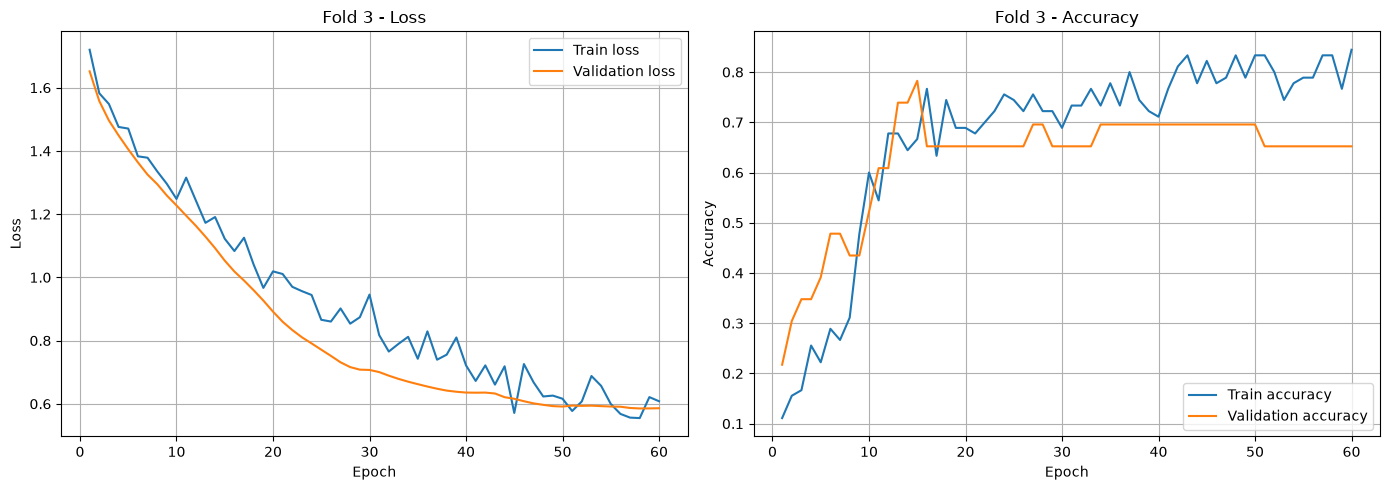


---------- FOLD 3 RESULTS ----------
Accuracy: 0.6522
Macro F1: 0.3565
Final train loss: 0.6081
Final validation loss: 0.5860

========== FOLD 4 ==========
Epoch 5/60 | train_loss=1.4618 | val_loss=1.5346 | train_acc=0.3297 | val_acc=0.3636
Epoch 10/60 | train_loss=1.0954 | val_loss=1.2273 | train_acc=0.6374 | val_acc=0.5909
Epoch 15/60 | train_loss=1.0539 | val_loss=1.0154 | train_acc=0.5934 | val_acc=0.7727
Epoch 20/60 | train_loss=0.9078 | val_loss=0.9095 | train_acc=0.6813 | val_acc=0.7727
Epoch 25/60 | train_loss=0.9116 | val_loss=0.8356 | train_acc=0.6374 | val_acc=0.7727
Epoch 30/60 | train_loss=0.7214 | val_loss=0.7934 | train_acc=0.7363 | val_acc=0.7727
Epoch 35/60 | train_loss=0.8631 | val_loss=0.7645 | train_acc=0.5604 | val_acc=0.7727
Epoch 40/60 | train_loss=0.7011 | val_loss=0.7525 | train_acc=0.7033 | val_acc=0.8182
Epoch 45/60 | train_loss=0.6566 | val_loss=0.7381 | train_acc=0.7143 | val_acc=0.7727
Epoch 50/60 | train_loss=0.7059 | val_loss=0.7152 | train_acc=0.7143 |

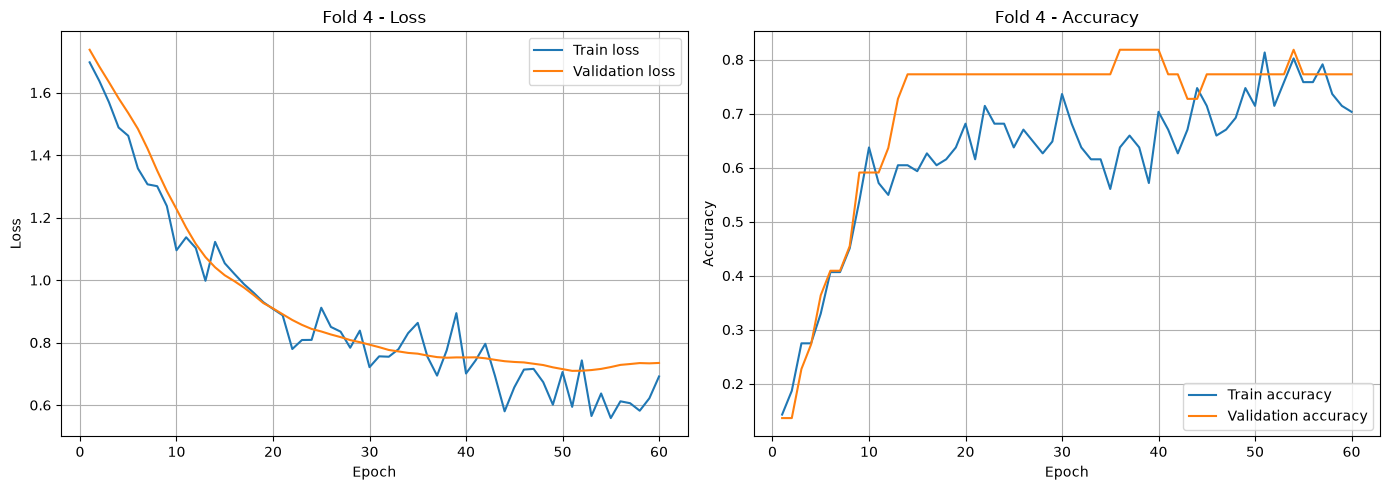


---------- FOLD 4 RESULTS ----------
Accuracy: 0.7727
Macro F1: 0.4752
Final train loss: 0.6916
Final validation loss: 0.7349

========== FOLD 5 ==========
Epoch 5/60 | train_loss=1.4925 | val_loss=1.5488 | train_acc=0.2967 | val_acc=0.1364
Epoch 10/60 | train_loss=1.3122 | val_loss=1.4078 | train_acc=0.4066 | val_acc=0.2727
Epoch 15/60 | train_loss=1.0846 | val_loss=1.2598 | train_acc=0.4835 | val_acc=0.4545
Epoch 20/60 | train_loss=1.0700 | val_loss=1.1238 | train_acc=0.4945 | val_acc=0.6818
Epoch 25/60 | train_loss=0.9072 | val_loss=0.9950 | train_acc=0.6374 | val_acc=0.6818
Epoch 30/60 | train_loss=0.8493 | val_loss=0.8965 | train_acc=0.5934 | val_acc=0.7273
Epoch 35/60 | train_loss=0.6865 | val_loss=0.8373 | train_acc=0.7033 | val_acc=0.7273
Epoch 40/60 | train_loss=0.7533 | val_loss=0.7859 | train_acc=0.6044 | val_acc=0.7273
Epoch 45/60 | train_loss=0.6848 | val_loss=0.7552 | train_acc=0.6593 | val_acc=0.7273
Epoch 50/60 | train_loss=0.7026 | val_loss=0.7361 | train_acc=0.7143 |

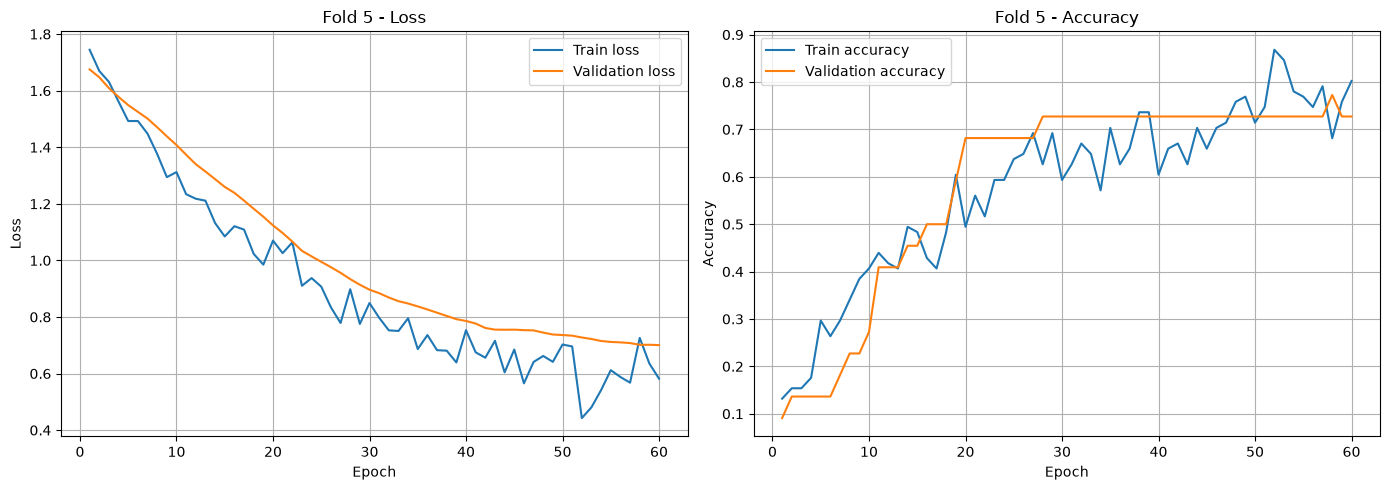


---------- FOLD 5 RESULTS ----------
Accuracy: 0.7273
Macro F1: 0.5452
Final train loss: 0.5819
Final validation loss: 0.7005

========== GENERAL RESULTS ==========
Mean Accuracy: 0.7087
Mean Macro F1: 0.4401

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

        Bach       0.93      0.83      0.88        30
   Beethoven       0.72      0.89      0.80        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.56      0.45      0.50        11
    Schubert       0.14      0.11      0.12         9

    accuracy                           0.71       113
   macro avg       0.47      0.46      0.46       113
weighted avg       0.66      0.71      0.68       113



In [225]:
import numpy as np
import torch
import torch.nn as nn

from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold

from torch.utils.data import TensorDataset, DataLoader

from evaluation import (
    train_and_evaluate_neural_network,
    plot_training_history
)


# ============================================================
# ARHITEKTURA
# ============================================================

class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# CUDA
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# LABEL ENCODING
# ============================================================

label_encoder_work = LabelEncoder()

y_work_encoded = label_encoder_work.fit_transform(
    y_work
)

print("Classes:", label_encoder_work.classes_)

print(
    "Class counts:",
    np.unique(
        y_work_encoded,
        return_counts=True
    )
)


# ============================================================
# FOLDOVI
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

work_folds = list(
    skf.split(
        X_work,
        y_work_encoded
    )
)


# ============================================================
# PARAMETRI
# ============================================================

EPOCHS = 60
BATCH_SIZE = 16
LEARNING_RATE = 0.001


# ============================================================
# REZULTATI
# ============================================================

fold_accuracies = []
fold_f1_scores = []

all_true = []
all_pred = []


# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    work_folds,
    start=1
):

    print(f"\n========== FOLD {fold} ==========")


    # ========================================================
    # TRAIN / TEST
    # ========================================================

    X_train = X_work[train_idx]
    y_train = y_work_encoded[train_idx]

    X_test = X_work[test_idx]
    y_test = y_work_encoded[test_idx]


    # ========================================================
    # STANDARDIZACIJA
    # ========================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # ========================================================
    # TENSORI
    # ========================================================

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )


    # ========================================================
    # DATALOADER
    # ========================================================

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # ========================================================
    # NOVA MREZA ZA SVAKI FOLD
    # ========================================================

    model = WorkNN_Compact(
        input_size=X_work.shape[1],
        num_classes=len(
            label_encoder_work.classes_
        )
    ).to(device)


    # ========================================================
    # LOSS
    # ========================================================

    criterion = nn.CrossEntropyLoss()


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-4
    )


    # ========================================================
    # TRENING + EVALUACIJA
    # ========================================================

    model, history = train_and_evaluate_neural_network(
        model=model,
        train_loader=train_loader,
        X_val=X_test,
        y_val=y_test,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        print_every=5
    )


    # ========================================================
    # GRAFICI
    # ========================================================

    plot_training_history(
        history,
        fold=fold
    )


    # ========================================================
    # FINALNE PREDIKCIJE
    # ========================================================

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).to(device)


    model.eval()

    with torch.no_grad():

        logits = model(
            X_test_tensor
        )

        predictions = torch.argmax(
            logits,
            dim=1
        ).cpu().numpy()


    # ========================================================
    # METRIKE
    # ========================================================

    accuracy = metrics.accuracy_score(
        y_test,
        predictions
    )

    f1 = metrics.f1_score(
        y_test,
        predictions,
        average="macro"
    )


    fold_accuracies.append(
        accuracy
    )

    fold_f1_scores.append(
        f1
    )

    all_true.extend(
        y_test
    )

    all_pred.extend(
        predictions
    )


    # ========================================================
    # ISPIS FOLDA
    # ========================================================

    print(
        f"\n---------- FOLD {fold} RESULTS ----------"
    )

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        f"Macro F1: {f1:.4f}"
    )

    print(
        f"Final train loss: "
        f"{history['train_loss'][-1]:.4f}"
    )

    print(
        f"Final validation loss: "
        f"{history['val_loss'][-1]:.4f}"
    )


# ============================================================
# GENERAL RESULTS
# ============================================================

print(
    "\n========== GENERAL RESULTS =========="
)

print(
    f"Mean Accuracy: "
    f"{np.mean(fold_accuracies):.4f}"
)

print(
    f"Mean Macro F1: "
    f"{np.mean(fold_f1_scores):.4f}"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    "\n========== CLASSIFICATION REPORT =========="
)

print(
    metrics.classification_report(
        all_true,
        all_pred,
        labels=range(
            len(label_encoder_work.classes_)
        ),
        target_names=
            label_encoder_work.classes_,
        zero_division=0
    )
)

<span style="font-size:20px">
Dakle, uspjeli smo da se mreza ne preprilagodi toliko podacima, ali smo morali da uzmemo jako malu mrezu sto nam je umanjilo prediktivne sposobnosti znacajno u ovako teskom problemu klasifikacije
</span>